# ASSIGNMENT 1 (Introduction to Data Science & Analytics)
I gave all the code explaination below the nottebook outputs.


In [1]:
import pandas as pd, numpy as np 
from sklearn.model_selection import train_test_split 
from sklearn.preprocessing import OneHotEncoder, StandardScaler 
from sklearn.compose import ColumnTransformer 
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline 
import matplotlib.pyplot as plt

df = pd.read_csv("C:/Users/Admin/OneDrive/Desktop/TCS notes/student_placement_synthetic.csv") 
df.head()

,branch,college_tier,cgpa,backlogs,coding_skills,dsa_score,aptitude_score,communication_skills,ml_knowledge,system_design,internships,projects_count,certifications,hackathons,open_source_contributions,extracurriculars,placement_status,salary_package_lpa
0,ECE,Tier-3,6.70,0,7.6,4.4,49.5,3.7,6.4,0.3,1,4,4,3,2,1,1,14.75
1,Chemical,Tier-2,5.70,0,5.4,7.9,72.0,8.3,6.3,1.9,0,4,0,0,0,0,0,NaN
2,EE,Tier-2,7.19,0,5.6,6.8,79.1,7.4,4.4,5.2,1,3,2,1,2,0,1,19.06
3,CE,Tier-2,6.48,0,5.2,3.1,48.4,5.0,1.1,6.7,1,4,3,0,0,0,0,NaN
4,CSE,Tier-2,6.71,1,5.9,4.7,61.2,4.3,2.7,2.8,1,2,0,3,0,1,1,13.42


# Explanation:
* pandas (pd) → Used for data manipulation
* numpy (np) → Used for numerical operations
* train_test_split → Splits data into training & testing sets
* StandardScaler → Normalizes data
* PCA → Dimensionality reduction
* matplotlib → Data visualization
* df.head() → shows first 5 rows to understand dataset structure.

In [2]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 18 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   branch                     100000 non-null  str    
 1   college_tier               100000 non-null  str    
 2   cgpa                       100000 non-null  float64
 3   backlogs                   100000 non-null  int64  
 4   coding_skills              100000 non-null  float64
 5   dsa_score                  100000 non-null  float64
 6   aptitude_score             100000 non-null  float64
 7   communication_skills       100000 non-null  float64
 8   ml_knowledge               100000 non-null  float64
 9   system_design              100000 non-null  float64
 10  internships                100000 non-null  int64  
 11  projects_count             100000 non-null  int64  
 12  certifications             100000 non-null  int64  
 13  hackathons                 100000 non-nul

,cgpa,backlogs,coding_skills,dsa_score,aptitude_score,communication_skills,ml_knowledge,system_design,internships,projects_count,certifications,hackathons,open_source_contributions,extracurriculars,placement_status,salary_package_lpa
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,68475.000000
mean,7.206381,0.547010,5.995147,5.500711,64.990511,5.990614,4.508752,4.008210,1.095040,2.397280,1.49985,0.745840,0.450990,1.151100,0.684750,17.308014
std,0.925235,0.862727,1.496302,1.781961,11.990892,1.496552,1.968278,1.778405,0.940264,1.242829,1.11407,0.884189,0.671061,0.965162,0.464618,2.601041
min,4.000000,0.000000,1.000000,1.000000,20.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,6.880000
25%,6.580000,0.000000,5.000000,4.300000,56.800000,5.000000,3.200000,2.800000,0.000000,1.000000,1.00000,0.000000,0.000000,0.000000,0.000000,15.530000
50%,7.210000,0.000000,6.000000,5.500000,65.000000,6.000000,4.500000,4.000000,1.000000,2.000000,1.00000,0.000000,0.000000,1.000000,1.000000,17.250000
75%,7.830000,1.000000,7.000000,6.700000,73.100000,7.000000,5.900000,5.200000,2.000000,3.000000,2.00000,1.000000,1.000000,2.000000,1.000000,19.040000
max,10.000000,3.000000,10.000000,10.000000,100.000000,10.000000,10.000000,10.000000,3.000000,5.000000,4.00000,3.000000,2.000000,3.000000,1.000000,28.330000


# Explanation:
* df.info() : Shows column names, data types, missing values
* df.describe() : Gives statistical summary : Mean, Min / Max, Standard deviation, Quartiles

In [3]:
df.isna().sum()

branch                           0
college_tier                     0
cgpa                             0
backlogs                         0
coding_skills                    0
dsa_score                        0
aptitude_score                   0
communication_skills             0
ml_knowledge                     0
system_design                    0
internships                      0
projects_count                   0
certifications                   0
hackathons                       0
open_source_contributions        0
extracurriculars                 0
placement_status                 0
salary_package_lpa           31525
dtype: int64

# Explanation:
* Counts missing (NULL) values in each column
* Helps identify columns that need cleaning

In [4]:
df['salary_package_lpa'] = df['salary_package_lpa'].fillna(df['salary_package_lpa'].mode()[0])
df.isna().sum()

branch                       0
college_tier                 0
cgpa                         0
backlogs                     0
coding_skills                0
dsa_score                    0
aptitude_score               0
communication_skills         0
ml_knowledge                 0
system_design                0
internships                  0
projects_count               0
certifications               0
hackathons                   0
open_source_contributions    0
extracurriculars             0
placement_status             0
salary_package_lpa           0
dtype: int64

# Explanation:
* Missing salary values replaced with mode (most frequent value)
* Ensures no missing data remains

In [5]:
df.columns = df.columns.str.strip()
df["salary_package_lpa"] = pd.to_numeric(df["salary_package_lpa"], errors="coerce")

# Explanation:
* Removes extra spaces in column names
* Converts salary column to numeric
* Invalid values become NaN

In [6]:
Q1 = df["salary_package_lpa"].quantile(0.25)
Q3 = df["salary_package_lpa"].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Limit:", lower_limit)
print("Upper Limit:", upper_limit)


Q1: 16.35
Q3: 18.16
IQR: 1.8099999999999987
Lower Limit: 13.635000000000003
Upper Limit: 20.875


# Explanation:
* Q1 (25%) → Lower quartile
* Q3 (75%) → Upper quartile
* IQR = Q3 - Q1
* Outliers are values : 
Below lower_limit, Above upper_limit

In [7]:
outliers = df[(df["salary_package_lpa"] < lower_limit) | 
              (df["salary_package_lpa"] > upper_limit)]

print("Outliers:")
print(outliers)

Outliers:
         branch college_tier  cgpa  backlogs  coding_skills  dsa_score  \
4           CSE       Tier-2  6.71         1            5.9        4.7   
8            CE       Tier-2  7.03         0            5.1        2.5   
12           IT       Tier-2  7.16         2            9.3        6.6   
26          CSE       Tier-1  8.83         0            7.2        8.3   
50     Chemical       Tier-1  7.21         0            8.1        7.1   
...         ...          ...   ...       ...            ...        ...   
99945       ECE       Tier-3  6.60         0            5.4        9.9   
99948       ECE       Tier-3  8.49         1            5.9        3.5   
99976        IT       Tier-3  7.82         0            3.6        3.0   
99989       ECE       Tier-3  7.94         1            7.3        7.8   
99993        ME       Tier-2  6.54         1            3.5        6.5   

       aptitude_score  communication_skills  ml_knowledge  system_design  \
4                61.2    

# Explanation:
* Filters rows where salary is outside normal range
* These are extreme/unusual values

In [8]:
df["Orders_Winsorized"] = np.where(df["salary_package_lpa"] > upper_limit, upper_limit,
        np.where(df["salary_package_lpa"] < lower_limit, lower_limit, df["salary_package_lpa"]))

# Explanation:

Replaces:
* High outliers → upper limit
* Low outliers → lower limit
* Keeps data but reduces impact of extreme values

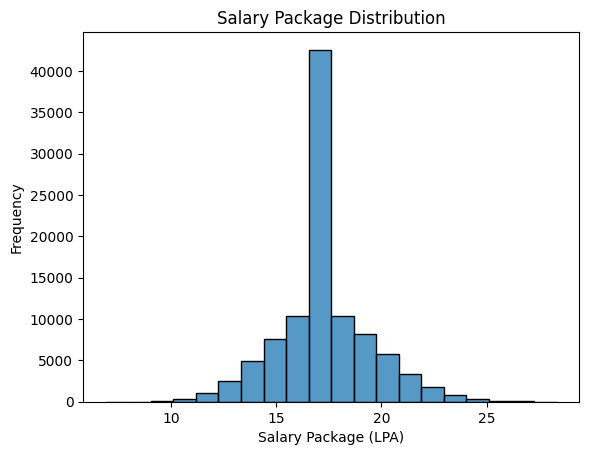

In [9]:
import seaborn as sns
sns.histplot(df["salary_package_lpa"], bins=20)
plt.title("Salary Package Distribution")
plt.xlabel("Salary Package (LPA)")
plt.ylabel("Frequency")
plt.show()

# Explanation:
* Creates histogram
* Shows distribution of salaries
* Helps understand : Skewness, Spread, Outliers visually

In [10]:
import pandas as pd

df = pd.read_csv("C:/Users/Admin/OneDrive/Desktop/TCS notes/student_placement_synthetic.csv")
df.head()

X = df.drop(columns=["placement_status", "salary_package_lpa"])
y = df["placement_status"]

X = pd.get_dummies(X, drop_first=True)

X = X.fillna(X.mean())

# Explanation:
* X (Features) → Input variables
* y (Target) → Placement status (output)
* Converts categorical variables into numeric
* Example : Gender → Male=0, Female=1
* drop_first=True avoids redundancy

In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)



# Explanation:
* Standardizes data : Mean = 0, Std = 1
* Important for PCA & LDA

In [12]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
print(pca.explained_variance_ratio_)

[0.08147199 0.05851868]


# Explanation:
* Reduces features to 2 principal components
* Keeps maximum variance
* explained_variance_ratio_ shows importance of each component

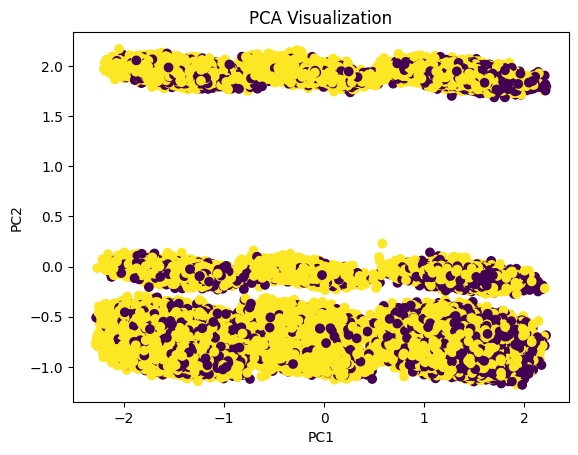

In [13]:
import matplotlib.pyplot as plt

plt.scatter(X_pca[:,0], X_pca[:,1], c=y, cmap='viridis')
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Visualization")
plt.show()

# Explanation:
* 2D visualization of data
* Points colored by placement status
* Helps identify patterns/clusters

In [14]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

lda = LinearDiscriminantAnalysis(n_components=1)
X_lda = lda.fit_transform(X_scaled, y)

# Explanation:
* LDA uses class labels (y)
* Maximizes separation between classes
* Reduces data to 1 dimension

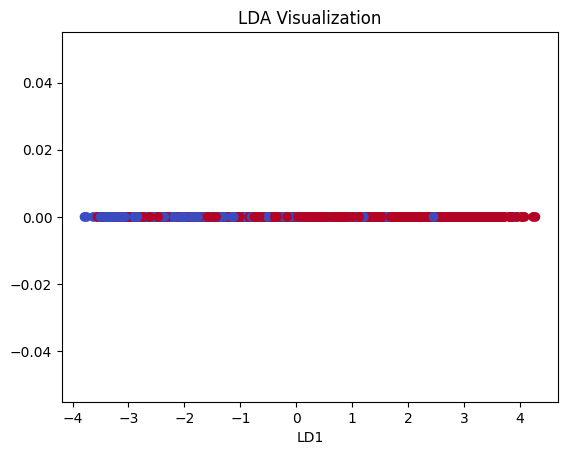

In [15]:
plt.scatter(X_lda, [0]*len(X_lda), c=y, cmap='coolwarm')
plt.title("LDA Visualization")
plt.xlabel("LD1")
plt.show()

# Explanation:
* Shows class separation on 1D axis
* Better for classification insight than PCA